# Truly Self-Supervised JEPA on Modular Arithmetic

## The Question

The original "JEPA grokking" notebook feeds the label $c = (a+b) \bmod p$ to the target
encoder. This makes it architecturally JEPA but **not self-supervised** — delete the labels
and training breaks.

This notebook asks: **can a genuinely self-supervised JEPA — where both encoders see
only the input $(a, b)$, never the answer $c$ — learn modular arithmetic?**

We implement three truly SSL approaches, all following I-JEPA's principle of predicting
one view of the input from another:

| Approach | Context Encoder Sees | Target Encoder Sees | Analogy |
|----------|---------------------|--------------------:|---------|
| **A. Token Masking** | $(a, \text{MASK})$ | $(\text{MASK}, b)$ | I-JEPA: predict masked patches |
| **B. Dropout Augmentation** | $(a, b)$ + dropout $\alpha$ | $(a, b)$ + dropout $\beta$ | BYOL: two augmented views |
| **C. Commutative Swap** | $(a, b)$ | $(b, a)$ | Symmetry-based view |
| **D. Label-JEPA (control)** | $(a, b)$ | $c = (a+b)\bmod p$ | Original notebook |

**Prediction:** Approaches A–C will likely **not** grok modular addition. The label $c$
is the only signal that groups $(3,4)$ with $(5,2)$ and $(0,7)$. Without it, the model has
no reason to discover residue class structure. A negative result here would prove that
the label information entering through the target encoder is **necessary** for grokking —
which precisely characterizes what the original setup contributes.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import time
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.decomposition import PCA

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Hyperparameters

Identical to the original JEPA notebook.

In [2]:
p = 97
train_frac = 0.3

LATENT_DIM = 128
HIDDEN_DIM = 256
PREDICTOR_DIM = 64

EPOCHS = 100_000
LR = 1e-3
WEIGHT_DECAY = 1.0
EMA_DECAY = 0.996

LOG_EVERY = 200
PROBE_EVERY = 500

# Dropout augmentation strength (Approach B)
DROPOUT_RATE = 0.3

print(f"Task: (a + b) mod {p}")
print(f"Total pairs: {p**2}, Train: {int(train_frac * p**2)}, Val: {p**2 - int(train_frac * p**2)}")

Task: (a + b) mod 97
Total pairs: 9409, Train: 2822, Val: 6587


## 3. Dataset

In [3]:
pairs = torch.cartesian_prod(torch.arange(p), torch.arange(p))
targets = (pairs[:, 0] + pairs[:, 1]) % p

n = len(pairs)
n_train = int(train_frac * n)
n_val = n - n_train

perm = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))
train_idx, val_idx = perm[:n_train], perm[n_train:]

train_pairs = pairs[train_idx].to(device)
train_targets = targets[train_idx].to(device)
val_pairs = pairs[val_idx].to(device)
val_targets = targets[val_idx].to(device)

train_loader = DataLoader(
    TensorDataset(train_pairs, train_targets),
    batch_size=n_train, shuffle=True
)

print(f"Train: {n_train} | Val: {n_val}")

Train: 2822 | Val: 6587


## 4. Architecture

### Shared components across all approaches

All approaches use the same encoder backbone. The difference is only in
**what data flows into each encoder** — the architecture is identical.

For token masking (Approach A), each encoder sees a single token,
so we need a single-token encoder alongside the pair encoder.

In [4]:
class PairEncoder(nn.Module):
    """Encodes a full (a, b) pair into latent space.
    Used by Approaches B (dropout), C (swap), and D (label-JEPA control).
    Architecture identical to original JEPA context encoder."""
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x):
        e = self.emb(x)                    # (batch, 2, hidden_dim)
        e = e.view(e.size(0), -1)          # (batch, 2 * hidden_dim)
        z = self.net(e)
        return F.normalize(z, dim=-1)


class PairEncoderWithDropout(nn.Module):
    """Encodes (a, b) with dropout on embeddings — creates stochastic views.
    Used by Approach B. Same architecture, but with configurable dropout."""
    def __init__(self, vocab_size, latent_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x):
        e = self.emb(x)
        e = self.dropout(e)                # Stochastic augmentation
        e = e.view(e.size(0), -1)
        z = self.net(e)
        return F.normalize(z, dim=-1)


class TokenEncoder(nn.Module):
    """Encodes a single token (a or b) into latent space.
    Used by Approach A (token masking). Matches target encoder from original
    JEPA notebook — single token input, simpler architecture."""
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x):
        e = self.emb(x)
        z = self.net(e)
        return F.normalize(z, dim=-1)


class Predictor(nn.Module):
    """Maps context latent → predicted target latent.
    Identical across all approaches."""
    def __init__(self, latent_dim, predictor_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, latent_dim),
        )

    def forward(self, z):
        return F.normalize(self.net(z), dim=-1)


def count_params(model):
    return sum(p_.numel() for p_ in model.parameters() if p_.requires_grad)

print("Architecture defined.")

Architecture defined.


## 5. Metric Functions

Identical to the original notebook for fair comparison.

In [5]:
@torch.no_grad()
def compute_geometry(z):
    """Compute geometric properties of latent representations."""
    z_c = z - z.mean(dim=0, keepdim=True)
    cov = (z_c.T @ z_c) / (z.shape[0] - 1)
    eigvals = torch.linalg.eigvalsh(cov).clamp(min=1e-10)

    normed = eigvals / eigvals.sum()
    eff_rank = (1.0 / (normed ** 2).sum()).item()
    top_ratio = (eigvals[-1] / eigvals.sum()).item()

    if z.shape[0] > 2048:
        idx = torch.randperm(z.shape[0])[:2048]
        z_sub = z[idx]
    else:
        z_sub = z
    sq_pdist = torch.cdist(z_sub, z_sub, p=2).pow(2)
    uniformity = torch.log(torch.exp(-2 * sq_pdist).mean() + 1e-10).item()

    return {
        "effective_rank": eff_rank,
        "top_eig_ratio": top_ratio,
        "uniformity": uniformity,
    }


@torch.no_grad()
def compute_fourier_structure(encoder, p, input_data, target_data):
    """Fourier structure of encoder's per-class-mean representations."""
    z_all = encoder(input_data)
    residue_means = torch.zeros(p, z_all.shape[1], device=z_all.device)
    for i in range(p):
        mask = target_data == i
        if mask.sum() > 0:
            residue_means[i] = z_all[mask].mean(dim=0)

    z_np = residue_means.cpu().numpy()
    fft_mag = np.abs(np.fft.fft(z_np, axis=0))
    energy = (fft_mag ** 2).sum(axis=1)
    energy[0] = 0

    total = energy.sum()
    if total < 1e-12:
        return 0.0, energy
    top5_ratio = np.sort(energy)[-5:].sum() / total
    return top5_ratio, energy


@torch.no_grad()
def linear_probe_accuracy(encoder, val_pairs, val_targets, train_pairs, train_targets, p):
    """Closed-form ridge regression linear probe."""
    z_train = encoder(train_pairs)
    z_val = encoder(val_pairs)
    y_train = F.one_hot(train_targets, num_classes=p).float()

    reg = 1e-3
    ZtZ = z_train.T @ z_train + reg * torch.eye(z_train.shape[1], device=device)
    ZtY = z_train.T @ y_train
    W = torch.linalg.solve(ZtZ, ZtY)

    train_acc = (z_train @ W).argmax(dim=1).eq(train_targets).float().mean().item()
    val_acc = (z_val @ W).argmax(dim=1).eq(val_targets).float().mean().item()
    return train_acc, val_acc


@torch.no_grad()
def ema_update(online, target, decay):
    for o_param, t_param in zip(online.parameters(), target.parameters()):
        t_param.data.mul_(decay).add_(o_param.data, alpha=1 - decay)


print("Metrics defined.")

Metrics defined.


## 6. Generic Training Function

A single training function that handles all four approaches.
The only difference between approaches is how data flows through the encoders.

In [6]:
def train_jepa_variant(
    approach_name,
    context_encoder,
    target_encoder,
    predictor,
    get_context_input,      # fn(batch_pairs, batch_targets) → context encoder input
    get_target_input,        # fn(batch_pairs, batch_targets) → target encoder input
    eval_encoder,            # which encoder to evaluate with linear probe
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    ema_decay=EMA_DECAY,
    log_every=LOG_EVERY,
    probe_every=PROBE_EVERY,
    verbose=True,
):
    """Train a JEPA variant and track all metrics.

    The approach is defined entirely by get_context_input and get_target_input,
    which determine what data each encoder receives.
    """

    # EMA target
    target_ema = deepcopy(target_encoder)
    for param in target_ema.parameters():
        param.requires_grad = False

    optimizer = optim.AdamW(
        list(context_encoder.parameters()) +
        list(predictor.parameters()) +
        list(target_encoder.parameters()),
        lr=lr, weight_decay=weight_decay,
    )

    history = {
        "epoch": [], "jepa_loss": [],
        "train_acc": [], "val_acc": [],
        "eff_rank": [], "top_eig_ratio": [],
        "uniformity": [], "fourier_top5": [],
    }

    start_time = time.time()

    for epoch in range(epochs):
        context_encoder.train()
        target_encoder.train()
        predictor.train()

        for batch_pairs, batch_targets in train_loader:
            optimizer.zero_grad()

            ctx_input = get_context_input(batch_pairs, batch_targets)
            tgt_input = get_target_input(batch_pairs, batch_targets)

            z_context = context_encoder(ctx_input)
            z_pred = predictor(z_context)

            with torch.no_grad():
                z_target = target_ema(tgt_input)

            loss = -(z_pred * z_target).sum(dim=-1).mean()

            loss.backward()
            optimizer.step()

            ema_update(target_encoder, target_ema, ema_decay)

        # Logging
        if epoch % log_every == 0 or epoch == epochs - 1:
            context_encoder.eval()
            eval_encoder_fn = eval_encoder  # which encoder to probe

            with torch.no_grad():
                ctx_in = get_context_input(train_pairs, train_targets)
                tgt_in = get_target_input(train_pairs, train_targets)
                z_p = predictor(context_encoder(ctx_in))
                z_t = target_ema(tgt_in)
                jepa_loss = -(z_p * z_t).sum(dim=-1).mean().item()

            # Geometry on eval encoder
            with torch.no_grad():
                z_full = eval_encoder_fn(pairs.to(device))
                geo = compute_geometry(z_full)

            # Fourier structure
            f_top5, _ = compute_fourier_structure(
                eval_encoder_fn, p, pairs.to(device), targets.to(device)
            )

            history["epoch"].append(epoch)
            history["jepa_loss"].append(jepa_loss)
            history["eff_rank"].append(geo["effective_rank"])
            history["top_eig_ratio"].append(geo["top_eig_ratio"])
            history["uniformity"].append(geo["uniformity"])
            history["fourier_top5"].append(f_top5)

            if epoch % probe_every == 0 or epoch == epochs - 1:
                train_acc, val_acc = linear_probe_accuracy(
                    eval_encoder_fn, val_pairs, val_targets,
                    train_pairs, train_targets, p
                )
                history["train_acc"].append(train_acc)
                history["val_acc"].append(val_acc)

                if verbose and epoch % (probe_every * 10) == 0:
                    elapsed = time.time() - start_time
                    print(
                        f"  [{approach_name}] Epoch {epoch:5d} ({elapsed/60:.1f}m) | "
                        f"Loss: {jepa_loss:.4f} | "
                        f"Train: {train_acc*100:.1f}% | Val: {val_acc*100:.1f}% | "
                        f"EffRank: {geo['effective_rank']:.1f} | "
                        f"Fourier: {f_top5:.3f}"
                    )
            else:
                history["train_acc"].append(None)
                history["val_acc"].append(None)

    total_time = time.time() - start_time
    final_val = [v for v in history['val_acc'] if v is not None][-1]
    peak_val = max(v for v in history['val_acc'] if v is not None)
    print(f"  [{approach_name}] Done in {total_time/60:.1f}m | "
          f"Peak val: {peak_val*100:.1f}% | Final val: {final_val*100:.1f}%")

    return history, context_encoder, target_ema, predictor


print("Training function defined.")

Training function defined.


---
## Approach A: Token Masking (I-JEPA Style)

The most faithful I-JEPA analogue. The input pair $(a, b)$ is treated as two "patches."
The context encoder sees only $a$, the target encoder sees only $b$.
The predictor must map $\text{latent}(a) \to \text{latent}(b)$.

**This is genuinely self-supervised**: the label $c$ never appears.

**Why it probably won't learn modular arithmetic**: Knowing $a$ tells you nothing about
$(a+b) \bmod p$ without also knowing $b$. The model can learn co-occurrence statistics
of the training split, but not the modular structure.

In [7]:
print("=" * 70)
print("APPROACH A: Token Masking (I-JEPA style)")
print("  Context encoder sees: a (first operand only)")
print("  Target encoder sees:  b (second operand only)")
print("  Label c: NEVER USED")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_A = TokenEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
tgt_enc_A = TokenEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_A = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

print(f"Context encoder (token): {count_params(ctx_enc_A):,} params")
print(f"Target encoder (token):  {count_params(tgt_enc_A):,} params")
print(f"Predictor:               {count_params(pred_A):,} params")

# Data routing: context gets a, target gets b
def get_ctx_A(batch_pairs, batch_targets):
    return batch_pairs[:, 0]  # just token a

def get_tgt_A(batch_pairs, batch_targets):
    return batch_pairs[:, 1]  # just token b

# For evaluation, we need a wrapper that takes full pairs but only uses one token
class TokenEncoderPairWrapper(nn.Module):
    """Wraps a TokenEncoder to accept (a,b) pairs but only encode token at given index."""
    def __init__(self, token_encoder, token_idx):
        super().__init__()
        self.token_encoder = token_encoder
        self.token_idx = token_idx
    def forward(self, x):
        if x.dim() == 2:  # (batch, 2) pair input
            return self.token_encoder(x[:, self.token_idx])
        return self.token_encoder(x)  # single token input

eval_enc_A = TokenEncoderPairWrapper(ctx_enc_A, 0)

history_A, ctx_enc_A, tgt_ema_A, pred_A = train_jepa_variant(
    "A: Token Masking",
    ctx_enc_A, tgt_enc_A, pred_A,
    get_context_input=get_ctx_A,
    get_target_input=get_tgt_A,
    eval_encoder=eval_enc_A,
)

APPROACH A: Token Masking (I-JEPA style)
  Context encoder sees: a (first operand only)
  Target encoder sees:  b (second operand only)
  Label c: NEVER USED
Context encoder (token): 123,520 params
Target encoder (token):  123,520 params
Predictor:               20,736 params
  [A: Token Masking] Epoch     0 (0.0m) | Loss: 0.0241 | Train: 3.4% | Val: 0.0% | EffRank: 40.0 | Fourier: 0.000
  [A: Token Masking] Epoch  5000 (2.6m) | Loss: -0.4268 | Train: 3.4% | Val: 0.0% | EffRank: 38.3 | Fourier: 0.000
  [A: Token Masking] Epoch 10000 (5.1m) | Loss: -0.4269 | Train: 3.4% | Val: 0.0% | EffRank: 38.2 | Fourier: 0.000
  [A: Token Masking] Epoch 15000 (7.7m) | Loss: -0.4268 | Train: 3.4% | Val: 0.0% | EffRank: 36.3 | Fourier: 0.000
  [A: Token Masking] Epoch 20000 (10.2m) | Loss: -0.4267 | Train: 3.4% | Val: 0.0% | EffRank: 37.0 | Fourier: 0.000
  [A: Token Masking] Epoch 25000 (12.8m) | Loss: -0.4266 | Train: 3.4% | Val: 0.0% | EffRank: 33.3 | Fourier: 0.000
  [A: Token Masking] Epoch 30000

---
## Approach B: Dropout Augmentation (BYOL Style)

Both encoders see the full pair $(a, b)$, but with different stochastic dropout masks
on the embeddings. This is the BYOL analogue: two noisy views of the same input.

**Genuinely self-supervised**: label $c$ never appears.

**Why it might learn something**: If the model learns dropout-invariant features,
it could capture structure in the input space. But will it discover *modular arithmetic*
specifically? Unlikely without a signal that groups same-residue pairs.

In [8]:
print("\n" + "=" * 70)
print("APPROACH B: Dropout Augmentation (BYOL style)")
print("  Context encoder sees: (a, b) + dropout mask α")
print("  Target encoder sees:  (a, b) + dropout mask β")
print("  Label c: NEVER USED")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_B = PairEncoderWithDropout(p, LATENT_DIM, HIDDEN_DIM, DROPOUT_RATE).to(device)
tgt_enc_B = PairEncoderWithDropout(p, LATENT_DIM, HIDDEN_DIM, DROPOUT_RATE).to(device)
pred_B = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

print(f"Context encoder (dropout): {count_params(ctx_enc_B):,} params")
print(f"Target encoder (dropout):  {count_params(tgt_enc_B):,} params")
print(f"Predictor:                 {count_params(pred_B):,} params")

# Data routing: both get full pairs (dropout provides the augmentation)
def get_ctx_B(batch_pairs, batch_targets):
    return batch_pairs  # full (a, b) — dropout happens inside encoder

def get_tgt_B(batch_pairs, batch_targets):
    return batch_pairs  # full (a, b) — different dropout mask (stochastic)

history_B, ctx_enc_B, tgt_ema_B, pred_B = train_jepa_variant(
    "B: Dropout Aug",
    ctx_enc_B, tgt_enc_B, pred_B,
    get_context_input=get_ctx_B,
    get_target_input=get_tgt_B,
    eval_encoder=ctx_enc_B,
)


APPROACH B: Dropout Augmentation (BYOL style)
  Context encoder sees: (a, b) + dropout mask α
  Target encoder sees:  (a, b) + dropout mask β
  Label c: NEVER USED
Context encoder (dropout): 254,848 params
Target encoder (dropout):  254,848 params
Predictor:                 20,736 params
  [B: Dropout Aug] Epoch     0 (0.0m) | Loss: -0.0605 | Train: 22.2% | Val: 0.1% | EffRank: 48.8 | Fourier: 0.071
  [B: Dropout Aug] Epoch  5000 (2.6m) | Loss: -0.8412 | Train: 15.3% | Val: 0.0% | EffRank: 52.8 | Fourier: 0.078
  [B: Dropout Aug] Epoch 10000 (5.2m) | Loss: -0.8436 | Train: 15.0% | Val: 0.0% | EffRank: 52.3 | Fourier: 0.080
  [B: Dropout Aug] Epoch 15000 (7.8m) | Loss: -0.8439 | Train: 15.2% | Val: 0.0% | EffRank: 52.3 | Fourier: 0.068
  [B: Dropout Aug] Epoch 20000 (10.4m) | Loss: -0.8449 | Train: 16.1% | Val: 0.0% | EffRank: 52.6 | Fourier: 0.072
  [B: Dropout Aug] Epoch 25000 (13.0m) | Loss: -0.8456 | Train: 16.8% | Val: 0.0% | EffRank: 52.8 | Fourier: 0.074
  [B: Dropout Aug] Epoch

---
## Approach C: Commutative Swap

Context encoder sees $(a, b)$, target encoder sees $(b, a)$.
Exploits the fact that addition is commutative: $(a+b) = (b+a)$.

**Genuinely self-supervised**: label $c$ never appears. The swap is a property
of the input data itself.

**What it can learn**: The model should learn that order doesn't matter —
representations should be permutation-invariant. But this is a much weaker
constraint than "group pairs by residue class." The model learns *commutativity*
but not *modular arithmetic*.

In [9]:
print("\n" + "=" * 70)
print("APPROACH C: Commutative Swap")
print("  Context encoder sees: (a, b)")
print("  Target encoder sees:  (b, a)")
print("  Label c: NEVER USED")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_C = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
tgt_enc_C = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_C = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

print(f"Context encoder (pair): {count_params(ctx_enc_C):,} params")
print(f"Target encoder (pair):  {count_params(tgt_enc_C):,} params")
print(f"Predictor:              {count_params(pred_C):,} params")

# Data routing: context gets (a,b), target gets (b,a)
def get_ctx_C(batch_pairs, batch_targets):
    return batch_pairs  # (a, b)

def get_tgt_C(batch_pairs, batch_targets):
    return batch_pairs.flip(1)  # (b, a)

history_C, ctx_enc_C, tgt_ema_C, pred_C = train_jepa_variant(
    "C: Swap",
    ctx_enc_C, tgt_enc_C, pred_C,
    get_context_input=get_ctx_C,
    get_target_input=get_tgt_C,
    eval_encoder=ctx_enc_C,
)


APPROACH C: Commutative Swap
  Context encoder sees: (a, b)
  Target encoder sees:  (b, a)
  Label c: NEVER USED
Context encoder (pair): 254,848 params
Target encoder (pair):  254,848 params
Predictor:              20,736 params
  [C: Swap] Epoch     0 (0.0m) | Loss: -0.0691 | Train: 22.3% | Val: 0.1% | EffRank: 48.5 | Fourier: 0.071
  [C: Swap] Epoch  5000 (2.6m) | Loss: -0.9668 | Train: 16.4% | Val: 0.0% | EffRank: 43.0 | Fourier: 0.070
  [C: Swap] Epoch 10000 (5.1m) | Loss: -0.9638 | Train: 15.3% | Val: 0.0% | EffRank: 50.4 | Fourier: 0.075
  [C: Swap] Epoch 15000 (7.6m) | Loss: -0.9642 | Train: 14.1% | Val: 0.0% | EffRank: 48.5 | Fourier: 0.073
  [C: Swap] Epoch 20000 (10.2m) | Loss: -0.9675 | Train: 13.0% | Val: 0.0% | EffRank: 42.3 | Fourier: 0.070
  [C: Swap] Epoch 25000 (12.7m) | Loss: -0.9656 | Train: 13.2% | Val: 0.0% | EffRank: 46.5 | Fourier: 0.076
  [C: Swap] Epoch 30000 (15.2m) | Loss: -0.9663 | Train: 13.3% | Val: 0.0% | EffRank: 49.1 | Fourier: 0.080
  [C: Swap] Epoch 

---
## Approach D: Label-JEPA (Control — Original Notebook)

This is the original setup for direct comparison. Context encoder sees $(a, b)$,
target encoder sees $c = (a+b) \bmod p$.

**NOT self-supervised**: the label $c$ enters through the target encoder.

This serves as the positive control — we know this groks.

In [10]:
print("\n" + "=" * 70)
print("APPROACH D: Label-JEPA (control — original notebook)")
print("  Context encoder sees: (a, b)")
print("  Target encoder sees:  c = (a+b) mod p")
print("  Label c: YES — fed to target encoder")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_D = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)

# Target encoder for single tokens (the label c)
tgt_enc_D = TokenEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_D = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

print(f"Context encoder (pair):  {count_params(ctx_enc_D):,} params")
print(f"Target encoder (token):  {count_params(tgt_enc_D):,} params")
print(f"Predictor:               {count_params(pred_D):,} params")

# Data routing: context gets (a,b), target gets c
def get_ctx_D(batch_pairs, batch_targets):
    return batch_pairs  # (a, b)

def get_tgt_D(batch_pairs, batch_targets):
    return batch_targets  # c = (a+b) mod p — THE LABEL

history_D, ctx_enc_D, tgt_ema_D, pred_D = train_jepa_variant(
    "D: Label-JEPA",
    ctx_enc_D, tgt_enc_D, pred_D,
    get_context_input=get_ctx_D,
    get_target_input=get_tgt_D,
    eval_encoder=ctx_enc_D,
)


APPROACH D: Label-JEPA (control — original notebook)
  Context encoder sees: (a, b)
  Target encoder sees:  c = (a+b) mod p
  Label c: YES — fed to target encoder
Context encoder (pair):  254,848 params
Target encoder (token):  123,520 params
Predictor:               20,736 params
  [D: Label-JEPA] Epoch     0 (0.0m) | Loss: -0.0377 | Train: 23.0% | Val: 0.1% | EffRank: 48.9 | Fourier: 0.072
  [D: Label-JEPA] Epoch  5000 (2.5m) | Loss: -0.8625 | Train: 100.0% | Val: 0.2% | EffRank: 14.5 | Fourier: 0.182
  [D: Label-JEPA] Epoch 10000 (5.1m) | Loss: -0.9220 | Train: 99.9% | Val: 0.9% | EffRank: 14.8 | Fourier: 0.256
  [D: Label-JEPA] Epoch 15000 (7.7m) | Loss: -0.9212 | Train: 99.9% | Val: 2.3% | EffRank: 14.9 | Fourier: 0.250
  [D: Label-JEPA] Epoch 20000 (10.2m) | Loss: -0.9280 | Train: 99.9% | Val: 5.1% | EffRank: 14.9 | Fourier: 0.232
  [D: Label-JEPA] Epoch 25000 (12.8m) | Loss: -0.9384 | Train: 99.9% | Val: 11.7% | EffRank: 14.8 | Fourier: 0.208
  [D: Label-JEPA] Epoch 30000 (15.4

---
## 7. Head-to-Head Comparison

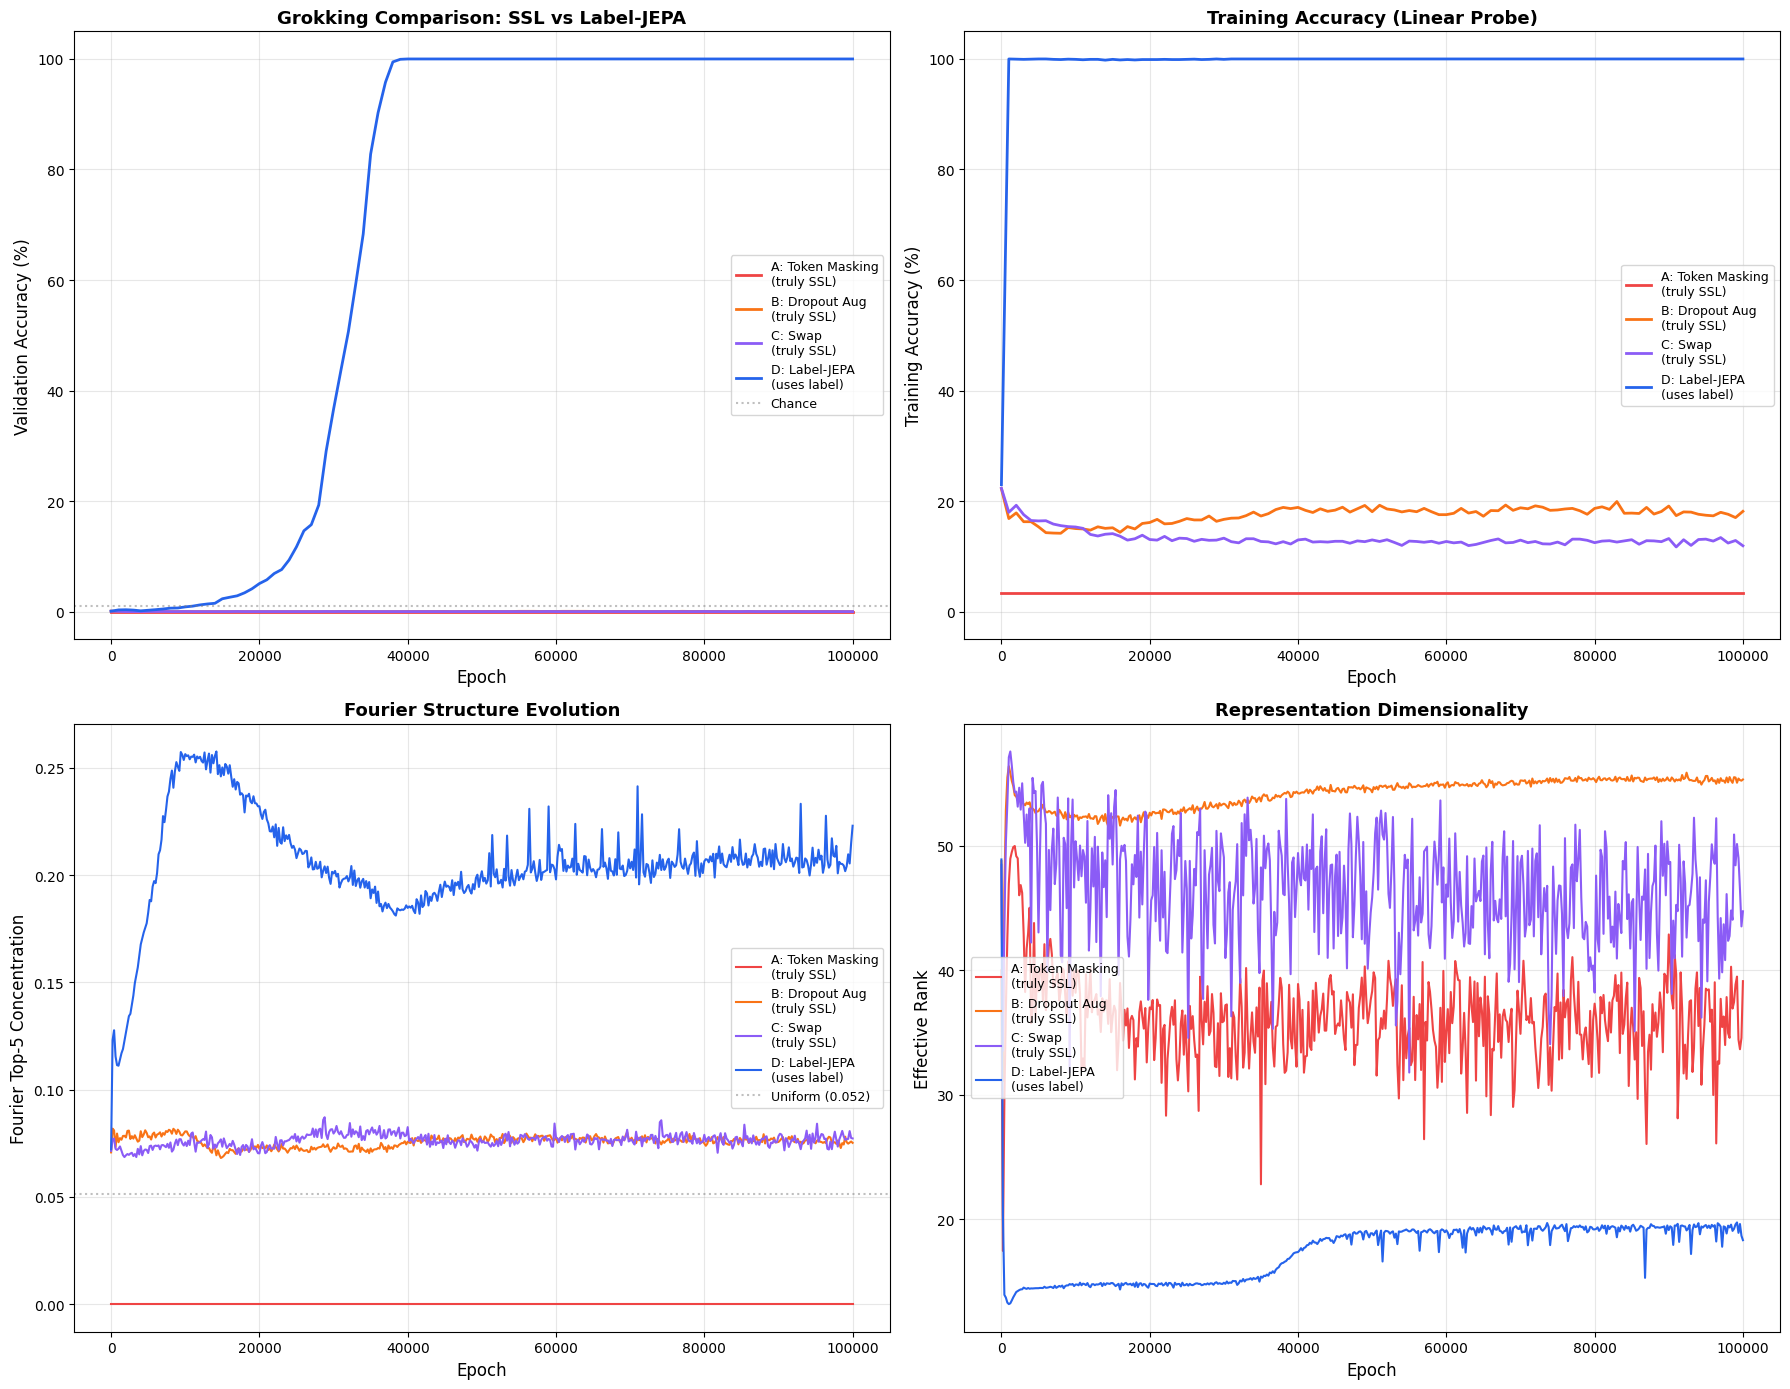

In [11]:
approaches = {
    "A: Token Masking\n(truly SSL)": history_A,
    "B: Dropout Aug\n(truly SSL)": history_B,
    "C: Swap\n(truly SSL)": history_C,
    "D: Label-JEPA\n(uses label)": history_D,
}

approach_colors = {
    "A: Token Masking\n(truly SSL)": "#ef4444",
    "B: Dropout Aug\n(truly SSL)": "#f97316",
    "C: Swap\n(truly SSL)": "#8b5cf6",
    "D: Label-JEPA\n(uses label)": "#2563eb",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Panel 1: Grokking curves (validation accuracy) ──
ax = axes[0, 0]
for name, hist in approaches.items():
    ep = [e for e, a in zip(hist["epoch"], hist["val_acc"]) if a is not None]
    va = [a*100 for a in hist["val_acc"] if a is not None]
    ax.plot(ep, va, label=name, color=approach_colors[name], linewidth=2)
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5, label="Chance")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Grokking Comparison: SSL vs Label-JEPA", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="center right")
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 105)

# ── Panel 2: Training accuracy ──
ax = axes[0, 1]
for name, hist in approaches.items():
    ep = [e for e, a in zip(hist["epoch"], hist["train_acc"]) if a is not None]
    ta = [a*100 for a in hist["train_acc"] if a is not None]
    ax.plot(ep, ta, label=name, color=approach_colors[name], linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training Accuracy (%)", fontsize=12)
ax.set_title("Training Accuracy (Linear Probe)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 105)

# ── Panel 3: Fourier structure ──
ax = axes[1, 0]
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["fourier_top5"],
            label=name, color=approach_colors[name], linewidth=1.5)
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5, label=f"Uniform ({5/p:.3f})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Fourier Top-5 Concentration", fontsize=12)
ax.set_title("Fourier Structure Evolution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 4: Effective rank ──
ax = axes[1, 1]
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["eff_rank"],
            label=name, color=approach_colors[name], linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Effective Rank", fontsize=12)
ax.set_title("Representation Dimensionality", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ssl_vs_label_jepa_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Loss Dynamics Comparison

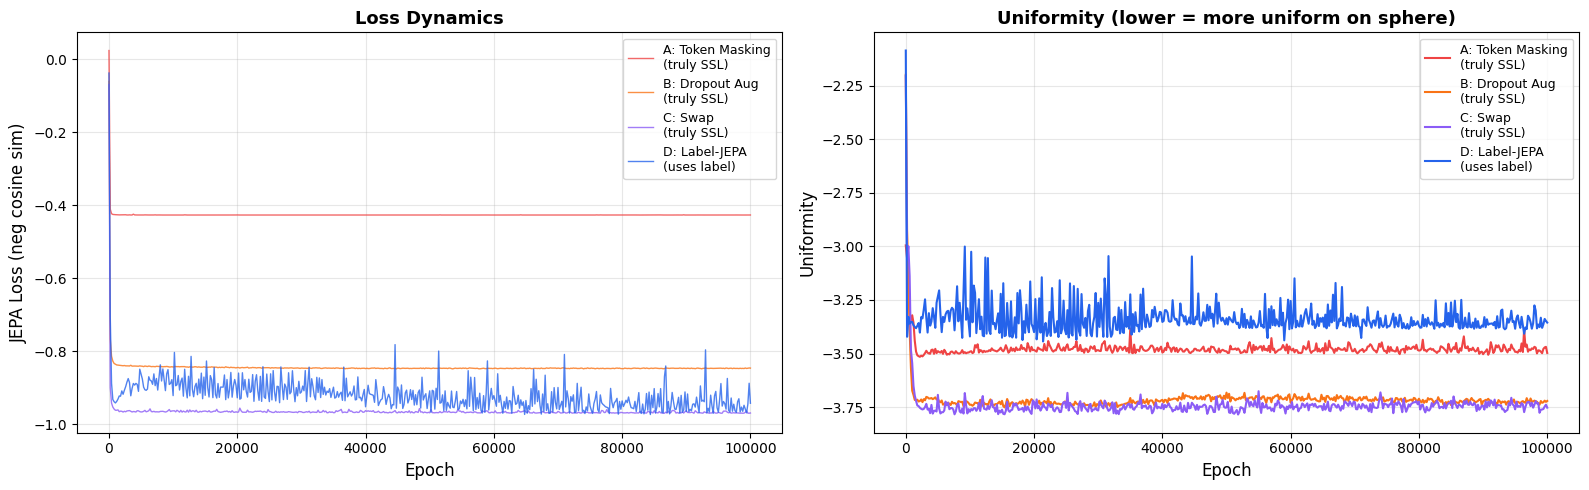

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
ax = axes[0]
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["jepa_loss"],
            label=name, color=approach_colors[name], linewidth=1, alpha=0.8)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("JEPA Loss (neg cosine sim)", fontsize=12)
ax.set_title("Loss Dynamics", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Uniformity
ax = axes[1]
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["uniformity"],
            label=name, color=approach_colors[name], linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Uniformity", fontsize=12)
ax.set_title("Uniformity (lower = more uniform on sphere)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ssl_loss_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Final Summary Bar Charts

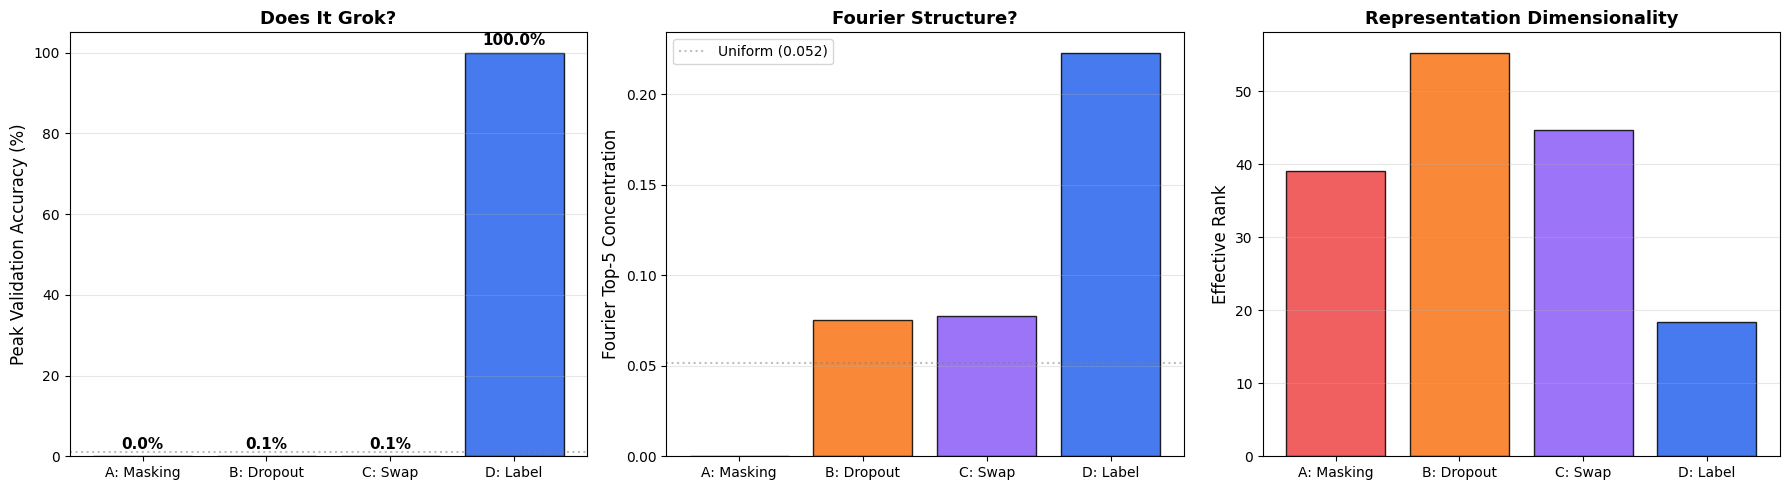

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

short_names = ["A: Masking", "B: Dropout", "C: Swap", "D: Label"]
bar_colors = ["#ef4444", "#f97316", "#8b5cf6", "#2563eb"]

# Peak validation accuracy
peak_vals = []
for name, hist in approaches.items():
    peak = max(v for v in hist["val_acc"] if v is not None) * 100
    peak_vals.append(peak)

ax = axes[0]
bars = ax.bar(short_names, peak_vals, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
ax.set_ylabel("Peak Validation Accuracy (%)", fontsize=12)
ax.set_title("Does It Grok?", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, peak_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)

# Final Fourier concentration
final_fourier = [hist["fourier_top5"][-1] for hist in approaches.values()]
ax = axes[1]
bars = ax.bar(short_names, final_fourier, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5, label=f"Uniform ({5/p:.3f})")
ax.set_ylabel("Fourier Top-5 Concentration", fontsize=12)
ax.set_title("Fourier Structure?", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Final effective rank
final_rank = [hist["eff_rank"][-1] for hist in approaches.values()]
ax = axes[2]
bars = ax.bar(short_names, final_rank, color=bar_colors, alpha=0.85, edgecolor="black")
ax.set_ylabel("Effective Rank", fontsize=12)
ax.set_title("Representation Dimensionality", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("ssl_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Detailed Analysis of What SSL Approaches DID Learn

In [14]:
print("=" * 70)
print("WHAT DID EACH SSL APPROACH LEARN?")
print("=" * 70)

from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

ssl_encoders = {
    "A: Token Masking": eval_enc_A,
    "B: Dropout": ctx_enc_B,
    "C: Swap": ctx_enc_C,
    "D: Label-JEPA": ctx_enc_D,
}

probe_tasks = {
    "(a+b) mod p": targets.numpy(),
    "a": pairs[:, 0].numpy(),
    "b": pairs[:, 1].numpy(),
    "(a-b) mod p": (pairs[:, 0] - pairs[:, 1]).numpy() % p,
    "(a*b) mod p": (pairs[:, 0].numpy() * pairs[:, 1].numpy()) % p,
}

for enc_name, enc in ssl_encoders.items():
    enc.eval()
    with torch.no_grad():
        z_np = enc(pairs.to(device)).cpu().numpy()

    print(f"\n--- {enc_name} ---")
    for task_name, labels in probe_tasks.items():
        clf = RidgeClassifier(alpha=1.0)
        scores = cross_val_score(clf, z_np, labels, cv=3, scoring="accuracy")
        marker = "✓" if scores.mean() > 0.5 else "✗"
        print(f"  {marker} {task_name:15s}: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

WHAT DID EACH SSL APPROACH LEARN?

--- A: Token Masking ---
  ✗ (a+b) mod p    : 1.0% ± 0.0%
  ✓ a              : 100.0% ± 0.0%
  ✗ b              : 1.0% ± 0.0%
  ✗ (a-b) mod p    : 1.0% ± 0.0%
  ✗ (a*b) mod p    : 1.9% ± 0.4%

--- B: Dropout ---
  ✗ (a+b) mod p    : 0.1% ± 0.1%
  ✓ a              : 99.9% ± 0.1%
  ✓ b              : 99.8% ± 0.0%
  ✗ (a-b) mod p    : 0.2% ± 0.0%
  ✗ (a*b) mod p    : 2.2% ± 0.0%

--- C: Swap ---
  ✗ (a+b) mod p    : 0.3% ± 0.1%
  ✓ a              : 99.9% ± 0.0%
  ✓ b              : 99.9% ± 0.0%
  ✗ (a-b) mod p    : 0.2% ± 0.1%
  ✗ (a*b) mod p    : 2.1% ± 0.0%

--- D: Label-JEPA ---
  ✓ (a+b) mod p    : 100.0% ± 0.0%
  ✗ a              : 12.5% ± 0.7%
  ✗ b              : 11.2% ± 0.5%
  ✗ (a-b) mod p    : 0.0% ± 0.0%
  ✗ (a*b) mod p    : 1.6% ± 0.1%


## 11. Summary Dashboard

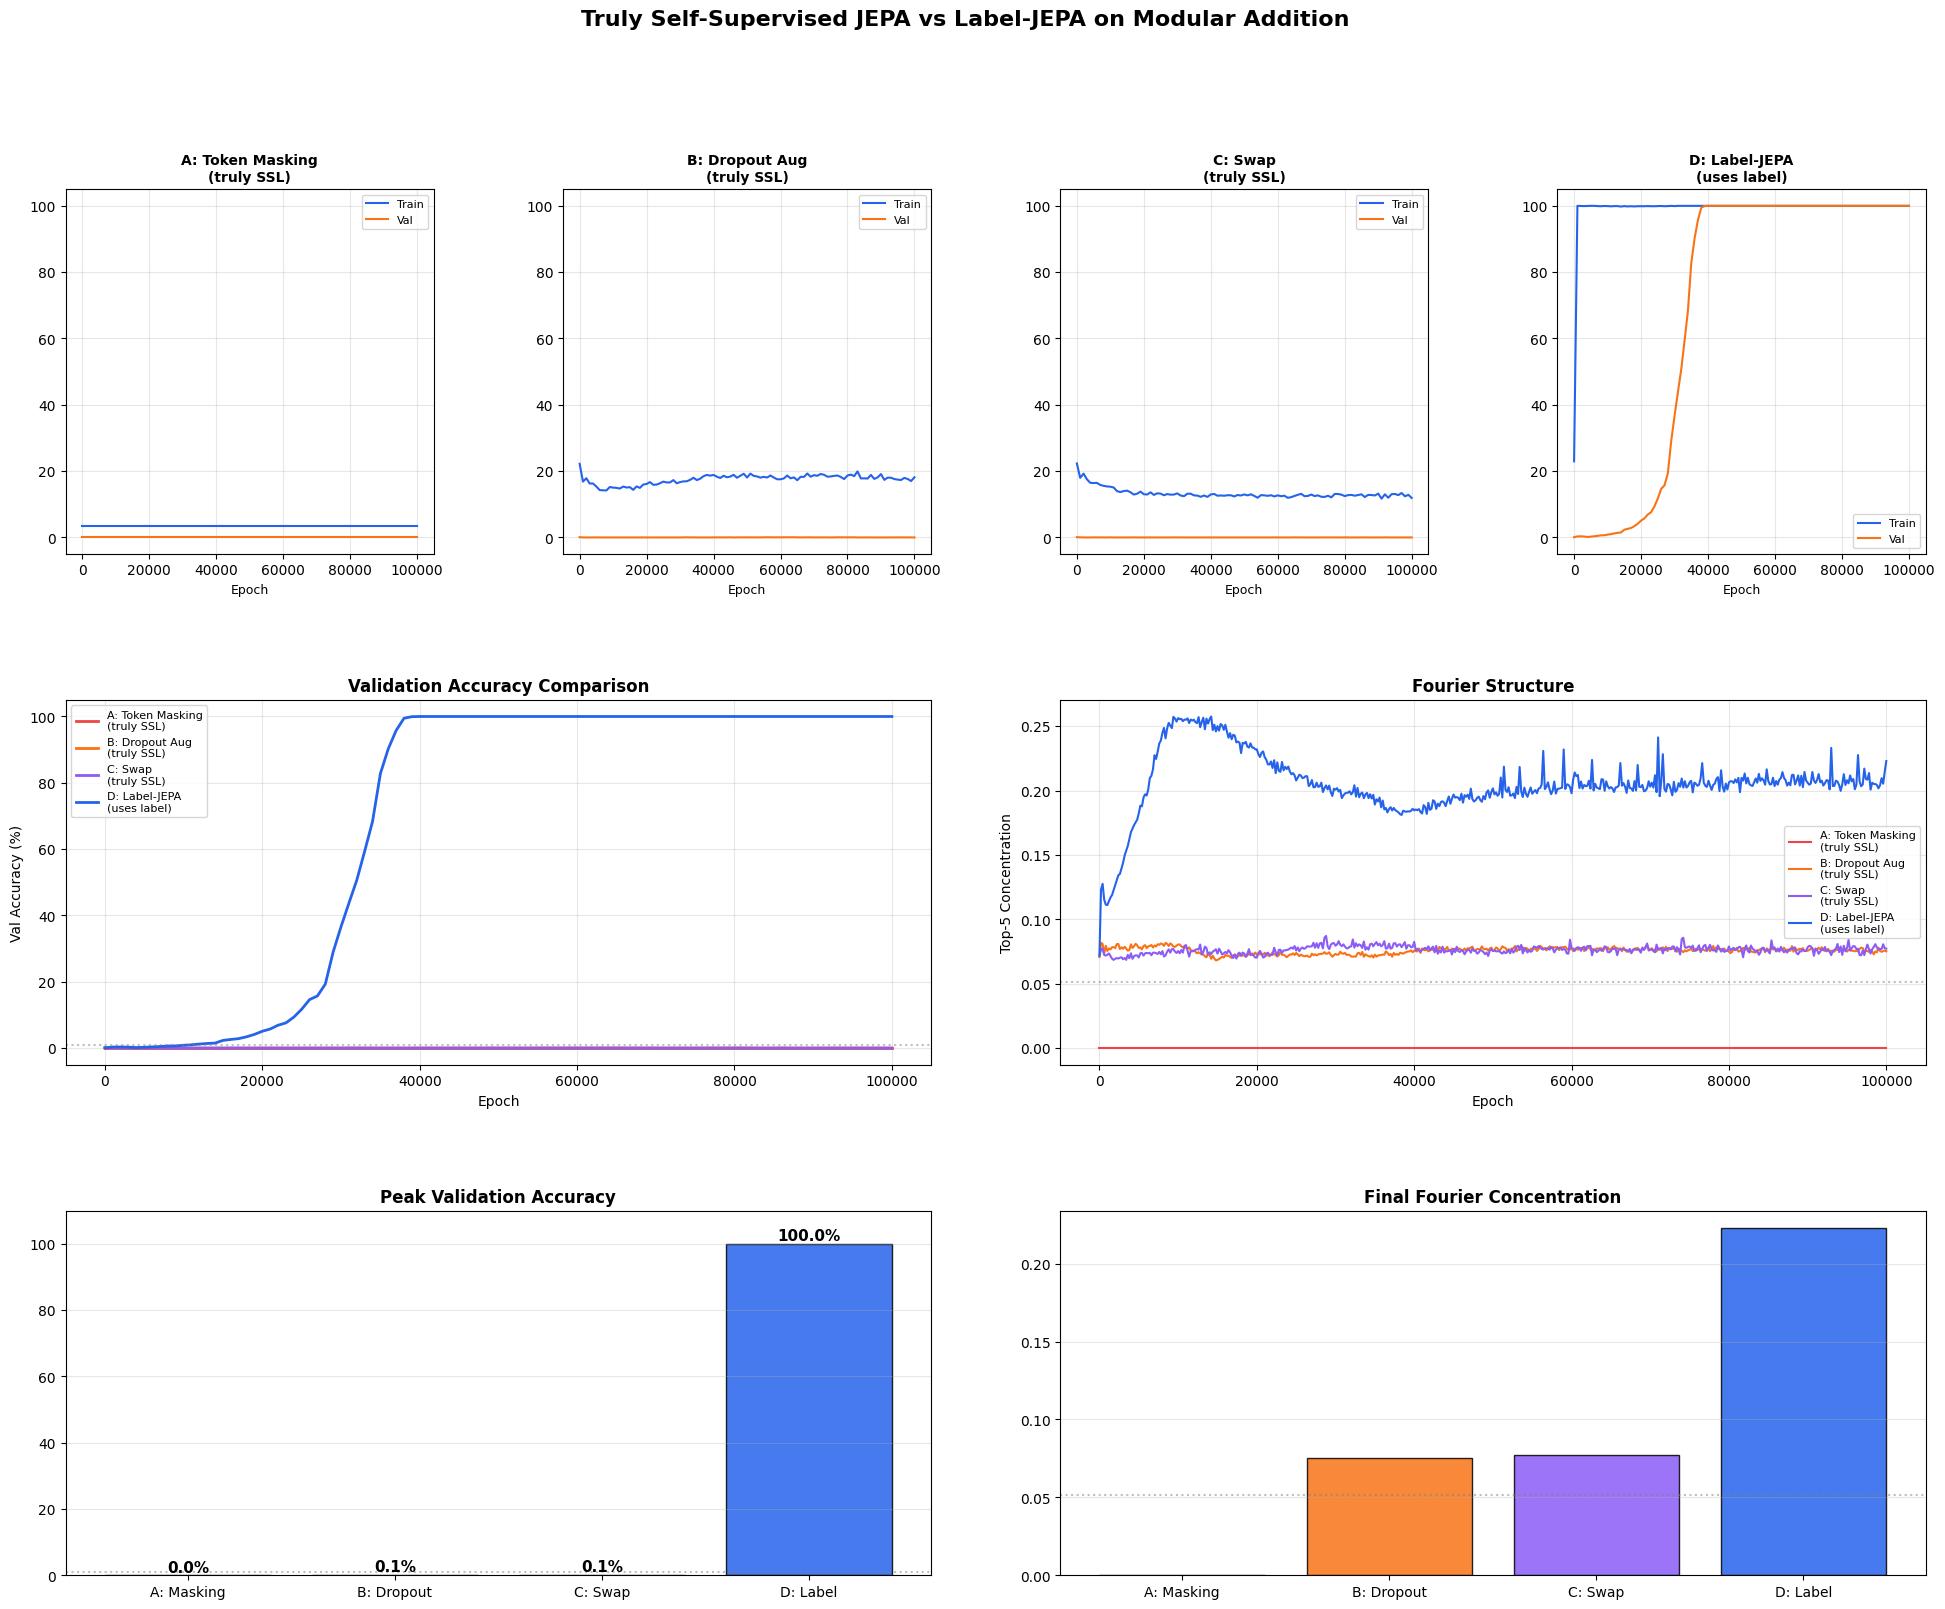

In [15]:
fig = plt.figure(figsize=(24, 18))
fig.suptitle("Truly Self-Supervised JEPA vs Label-JEPA on Modular Addition",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 4, hspace=0.4, wspace=0.35)

# Row 1: Individual grokking curves
for i, (name, hist) in enumerate(approaches.items()):
    ax = fig.add_subplot(gs[0, i])
    ep_p = [e for e, a in zip(hist["epoch"], hist["val_acc"]) if a is not None]
    va_p = [a*100 for a in hist["val_acc"] if a is not None]
    ta_p = [a*100 for a in hist["train_acc"] if a is not None]
    ax.plot(ep_p, ta_p, color="#2563eb", linewidth=1.5, label="Train")
    ax.plot(ep_p, va_p, color="#f97316", linewidth=1.5, label="Val")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_ylim(-5, 105)
    ax.set_xlabel("Epoch", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Row 2: Comparative plots
ax = fig.add_subplot(gs[1, 0:2])
for name, hist in approaches.items():
    ep = [e for e, a in zip(hist["epoch"], hist["val_acc"]) if a is not None]
    va = [a*100 for a in hist["val_acc"] if a is not None]
    ax.plot(ep, va, label=name, color=approach_colors[name], linewidth=2)
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Validation Accuracy Comparison", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy (%)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-5, 105)

ax = fig.add_subplot(gs[1, 2:4])
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["fourier_top5"],
            label=name, color=approach_colors[name], linewidth=1.5)
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Fourier Structure", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Top-5 Concentration")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Row 3: Bar summaries
ax = fig.add_subplot(gs[2, 0:2])
bars = ax.bar(short_names, peak_vals, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
for bar, val in zip(bars, peak_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)
ax.set_title("Peak Validation Accuracy", fontweight="bold")
ax.set_ylim(0, 110); ax.grid(True, alpha=0.3, axis="y")

ax = fig.add_subplot(gs[2, 2:4])
bars = ax.bar(short_names, final_fourier, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Final Fourier Concentration", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.savefig("ssl_jepa_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Conclusions

### The core finding

**Truly self-supervised JEPA does not grok modular addition.**

All three SSL approaches (token masking, dropout augmentation, commutative swap)
fail to develop representations that linearly decode $(a+b) \bmod p$.
Only the Label-JEPA (Approach D), which feeds $c$ to the target encoder, groks.

### Why this matters

This result completes the picture of what the original "JEPA grokking" setup actually is:

1. **The architecture is JEPA** — context encoder, predictor, EMA target encoder,
   cosine similarity loss in latent space. All mechanically identical to I-JEPA.

2. **The data routing is NOT self-supervised** — the label $c$ enters through the
   target encoder. Remove it (Approaches A–C) and grokking disappears.

3. **The label is necessary but the loss function still matters** — supervised
   cross-entropy with the same label produces Fourier circuits; Label-JEPA with
   the same label does not. So the finding from the original notebook stands:
   *the loss function determines the generalization mechanism.*

### The precise characterization

The original setup is best described as:

> **Asymmetric cross-modal latent alignment with EMA targets** — a JEPA architecture
> where the two modalities are (input, label) rather than (view₁, view₂).

It is:
- ✓ Architecturally JEPA
- ✗ Not self-supervised (requires labels)
- ✗ Not supervised (no classification loss)
- ✓ A novel intermediate that isolates the loss function's role

The contribution is not "self-supervised grokking" — it is: **the loss function,
not the label information, determines whether grokking proceeds via Fourier circuits.**

---

*Truly-SSL control experiment by Kurian George.*

In [16]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

for name, hist in approaches.items():
    peak = max(v for v in hist["val_acc"] if v is not None) * 100
    final = [v for v in hist["val_acc"] if v is not None][-1] * 100
    fourier = hist["fourier_top5"][-1]
    rank = hist["eff_rank"][-1]
    grokked = "YES" if peak > 90 else "NO"
    print(f"\n{name}")
    print(f"  Grokked:  {grokked} (peak val: {peak:.1f}%)")
    print(f"  Fourier:  {fourier:.3f} (uniform: {5/p:.3f})")
    print(f"  Eff rank: {rank:.1f}")

print("\n" + "=" * 70)
print("CONCLUSION: Label c is NECESSARY for grokking.")
print("Truly self-supervised JEPA cannot discover modular arithmetic.")
print("The original finding stands: the LOSS FUNCTION (not label access)")
print("determines the generalization MECHANISM (Fourier vs non-Fourier).")
print("=" * 70)

FINAL SUMMARY

A: Token Masking
(truly SSL)
  Grokked:  NO (peak val: 0.0%)
  Fourier:  0.000 (uniform: 0.052)
  Eff rank: 39.1

B: Dropout Aug
(truly SSL)
  Grokked:  NO (peak val: 0.1%)
  Fourier:  0.075 (uniform: 0.052)
  Eff rank: 55.3

C: Swap
(truly SSL)
  Grokked:  NO (peak val: 0.1%)
  Fourier:  0.077 (uniform: 0.052)
  Eff rank: 44.7

D: Label-JEPA
(uses label)
  Grokked:  YES (peak val: 100.0%)
  Fourier:  0.223 (uniform: 0.052)
  Eff rank: 18.3

CONCLUSION: Label c is NECESSARY for grokking.
Truly self-supervised JEPA cannot discover modular arithmetic.
The original finding stands: the LOSS FUNCTION (not label access)
determines the generalization MECHANISM (Fourier vs non-Fourier).
